# EDA

This first part focuses on data exploration and manipulation.

In [47]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matchms
import pickle

In [48]:
# filename = "ALL_GNPS_20200511.json"
# spectra = matchms.load_from_json(f"src/data/{filename}")

# list_spectra = list(spectra)
# print(f"Number of spectra: {len(list_spectra)}")

# with open("src/data/gnps_spectra.pkl", "wb") as f:
#     pickle.dump(list_spectra, f)

In [49]:
with open("src/data/gnps_spectra.pkl", "rb") as f:
    spectra = pickle.load(f)

In [50]:
type(spectra[0])

matchms.Spectrum.Spectrum

In [51]:
for spectrum in spectra[:5]:
  print(f"m/z range: {spectrum.peaks.mz.min()} - {spectrum.peaks.mz.max()}")

m/z range: 289.286377 - 982.221924
m/z range: 278.049927 - 940.88324
m/z range: 128.838745 - 455.885986
m/z range: 343.896484 - 546.972168
m/z range: 101.015465 - 1097.665161


### Different molecules have different m/z range

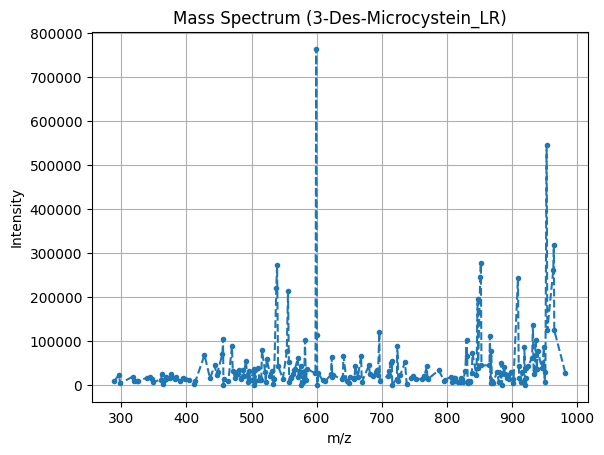

In [52]:
plt.plot(spectra[0].peaks.mz, spectra[0].peaks.intensities, '--.')
plt.xlabel("m/z")
plt.ylabel("Intensity")
plt.title(f"Mass Spectrum ({spectra[0].metadata.get('compound_name', 'Unknown')})")
plt.grid()
plt.show()

### To compute spectral similarity, normalization is needed

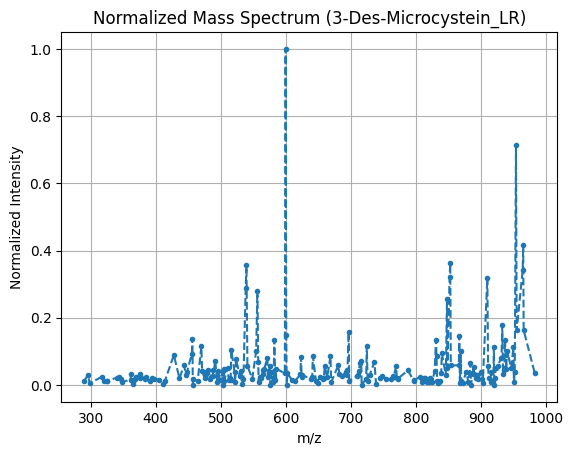

In [53]:
# normalize intensities to [0, 1]
normalized_intensities = spectra[0].peaks.intensities / np.max(spectra[0].peaks.intensities)
plt.plot(spectra[0].peaks.mz, normalized_intensities, '--.')
plt.xlabel("m/z")
plt.ylabel("Normalized Intensity")
plt.title(f"Normalized Mass Spectrum ({spectra[0].metadata.get('compound_name', 'Unknown')})")
plt.grid()
plt.show()

### Now we can try to visually compare intensities

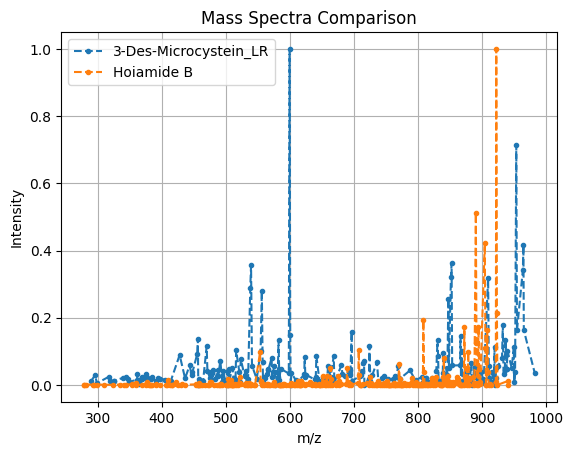

In [54]:
normalized1 = spectra[0].peaks.intensities / np.max(spectra[0].peaks.intensities)
normalized2 = spectra[1].peaks.intensities / np.max(spectra[1].peaks.intensities)
plt.plot(spectra[0].peaks.mz, normalized1, '--.', label=f"{spectra[0].metadata.get('compound_name', 'Unknown')}")
plt.plot(spectra[1].peaks.mz, normalized2, '--.', label=f"{spectra[1].metadata.get('compound_name', 'Unknown')}")
plt.xlabel("m/z")
plt.ylabel("Intensity")
plt.title("Mass Spectra Comparison")
plt.legend()
plt.grid()
plt.show()

In [55]:
# # check if sum of normalized intensities is 1
# print(f"Sum of normalized intensities (spectrum 1): {np.sum(normalized1)}")
# print(f"Sum of normalized intensities (spectrum 2): {np.sum(normalized2)}")

### Preprocessing

In [56]:
import matchms.filtering as ms_filters

def metadata_processing(spectrum):
    spectrum = ms_filters.default_filters(spectrum)
    # spectrum = ms_filters.repair_inchi_inchikey_smiles(spectrum)
    # spectrum = ms_filters.derive_inchi_from_smiles(spectrum)
    # spectrum = ms_filters.derive_smiles_from_inchi(spectrum)
    # spectrum = ms_filters.derive_inchikey_from_inchi(spectrum)
    spectrum = ms_filters.harmonize_undefined_smiles(spectrum)
    spectrum = ms_filters.harmonize_undefined_inchi(spectrum)
    spectrum = ms_filters.harmonize_undefined_inchikey(spectrum)
    spectrum = ms_filters.add_precursor_mz(spectrum)
    return spectrum

def peak_processing(spectrum):
    spectrum = ms_filters.default_filters(spectrum)
    spectrum = ms_filters.normalize_intensities(spectrum)
    spectrum = ms_filters.select_by_intensity(spectrum, intensity_from=0.01)
    spectrum = ms_filters.select_by_mz(spectrum, mz_from=10, mz_to=1000)
    return spectrum

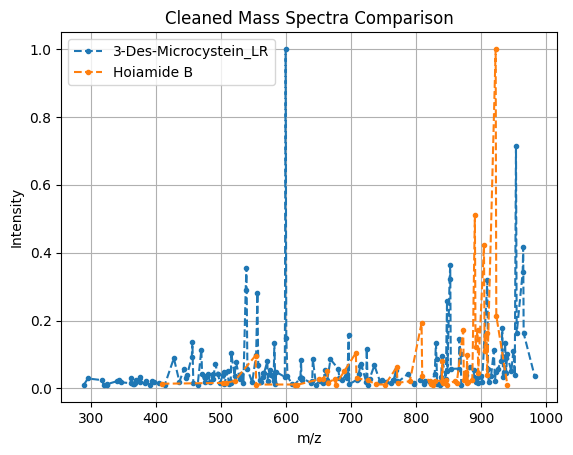

In [57]:
clean1 = metadata_processing(spectra[0])
clean2 = metadata_processing(spectra[1])

clean1 = peak_processing(spectra[0])
clean2 = peak_processing(spectra[1])

normalized1 = clean1.peaks.intensities / np.max(clean1.peaks.intensities)
normalized2 = clean2.peaks.intensities / np.max(clean2.peaks.intensities)

plt.plot(clean1.peaks.mz, normalized1, '--.', label=f"{spectra[0].metadata.get('compound_name', 'Unknown')}")
plt.plot(clean2.peaks.mz, normalized2, '--.', label=f"{spectra[1].metadata.get('compound_name', 'Unknown')}")
plt.xlabel("m/z")
plt.ylabel("Intensity")
plt.title("Cleaned Mass Spectra Comparison")
plt.legend()
plt.grid()
plt.show()

In [58]:
print(f"{len(spectra[0].peaks.mz)} -> {len(clean1.peaks.mz)}")
print(f"{len(spectra[0].peaks.intensities)} -> {len(clean1.peaks.intensities)}")

218 -> 186
218 -> 186


### Cosine similarity

In [59]:
# compute cosine similarity between the two spectra

from matchms import calculate_scores
from matchms.similarity import CosineGreedy
similarity_measure = CosineGreedy(tolerance=0.005)

spectrums = [spectra[0], spectra[1]]

scores = calculate_scores(spectrums, spectrums, similarity_measure, is_symmetric=True)

Calculating similarities: 100%|██████████████████████████████████████████████| 2/2 [00:00<00:00, 640.99it/s]


In [60]:
scores.score_names

('CosineGreedy_score', 'CosineGreedy_matches')

In [61]:
scores.scores['CosineGreedy_score']

(array([0, 0, 1, 1]),
 array([0, 1, 0, 1]),
 array([1.00000000e+00, 3.47802614e-06, 3.47802614e-06, 1.00000000e+00]))

In [62]:
row, col, val = scores.scores['CosineGreedy_score']

n = len(spectrums)
S = np.zeros((n, n))

S[row, col] = val

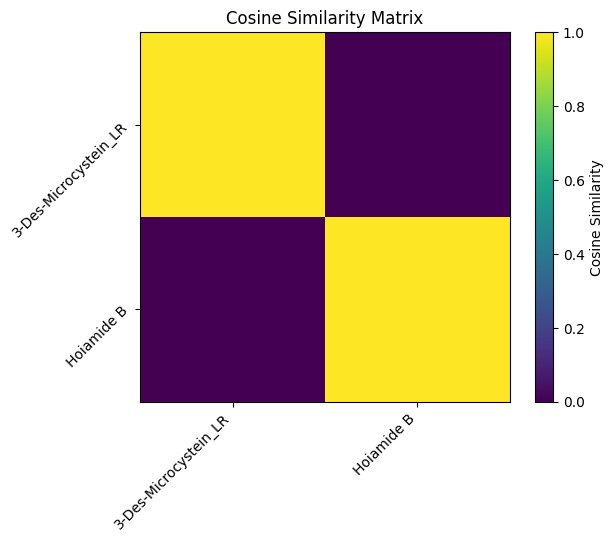

In [63]:
plt.imshow(S, cmap='viridis', vmin=0, vmax=1)
plt.title("Cosine Similarity Matrix")
plt.xticks(ticks=np.arange(n), labels=[s.metadata.get('compound_name', 'Unknown') for s in spectrums], rotation=45, ha='right')
plt.yticks(ticks=np.arange(n), labels=[s.metadata.get('compound_name', 'Unknown') for s in spectrums], rotation=45, ha='right')
plt.colorbar(label='Cosine Similarity')
plt.show()

### Spec2Vec

1. Data preparation (cleaning and subsampling)
2. Convert spectra into documents ("peak@xxx")
3. Convert words into vectors = Train word2vec with CBOW
4. Build spectrum vectors, normalize and compute similarities

In [64]:
import random

samples = random.sample(spectra, 1000)

In [65]:
import logging
logging.getLogger("matchms").setLevel(logging.ERROR)

cleaned_samples = []
for spec in samples:
  clean = metadata_processing(spec)
  clean = peak_processing(clean)
  cleaned_samples.append(clean)

In [66]:
## manual implementation for tokenization of spectra for Word2Vec training

# sentences = []
# for spec in cleaned_samples:
#     tokens = []
#     for mz in spec.mz:
#         token = f"peak@{round(mz,2)}"
#         tokens.append(token)
#     sentences.append(tokens)

# print(sentences[0])

## output: ['peak@81.02', 'peak@136.07', 'peak@192.1', 'peak@194.08', 'peak@207.1', 'peak@221.11', 'peak@334.16', 'peak@346.2', 'peak@392.2', 'peak@446.25', 'peak@546.3', 'peak@576.31']

In [67]:
def is_valid_spectrum(spec, min_peaks=5):
    try:
        return len(spec.peaks.mz) >= min_peaks
    except:
        return False

def normalize_spectrum(spectrum):
    mz = spectrum.peaks.mz
    intensity = spectrum.peaks.intensities
    intensity = intensity / intensity.sum()   # L1 normalization

    # construct a new spectrum object with normalized intensities
    spectrum = matchms.Spectrum(mz=mz, intensities=intensity, metadata=spectrum.metadata)
    return spectrum

valid_samples = [normalize_spectrum(s) for s in cleaned_samples if is_valid_spectrum(s)]

In [68]:
len(valid_samples)

751

In [69]:
from spec2vec import SpectrumDocument

sentences = [SpectrumDocument(s, n_decimals=2) for s in valid_samples]

In [70]:
print(sentences[0].words)

['peak@131.05', 'peak@133.06', 'peak@135.03', 'peak@139.04', 'peak@145.04', 'peak@150.04', 'peak@151.04', 'peak@157.07', 'peak@159.04', 'peak@161.04', 'peak@169.06', 'peak@170.08', 'peak@171.08', 'peak@172.00', 'peak@173.06', 'peak@175.03', 'peak@177.03', 'peak@180.04', 'peak@185.06', 'peak@186.07', 'peak@187.07', 'peak@188.06', 'peak@189.06', 'peak@190.05', 'peak@197.04', 'peak@198.05', 'peak@199.06', 'peak@201.06', 'peak@203.06', 'peak@211.07', 'peak@212.07', 'peak@213.07', 'peak@214.06', 'peak@215.06', 'peak@216.21', 'peak@217.04', 'peak@218.05', 'peak@227.08', 'peak@228.07', 'peak@229.08', 'peak@230.07', 'peak@231.06', 'peak@232.06', 'peak@233.07', 'peak@238.06', 'peak@239.06', 'peak@240.06', 'peak@241.05', 'peak@242.05', 'peak@243.05', 'peak@244.05', 'peak@245.06', 'peak@253.05', 'peak@255.06', 'peak@256.06', 'peak@257.07', 'peak@258.07', 'peak@259.05', 'peak@260.06', 'peak@269.05', 'peak@271.08', 'peak@272.08', 'peak@273.07', 'peak@274.07', 'peak@281.07', 'peak@283.05', 'peak@284

In [71]:
# training

from spec2vec.model_building import train_new_word2vec_model

model_file = "src/data/models/intro.model"
model = train_new_word2vec_model(sentences, iterations=[20], filename=model_file,
                                 workers=2, progress_logger=True)

  Epoch 1 of 20.Change in loss after epoch 1: 179441.921875
  Epoch 2 of 20.Change in loss after epoch 2: 180999.578125
  Epoch 3 of 20.Change in loss after epoch 3: 176708.75
  Epoch 4 of 20.Change in loss after epoch 4: 107537.6875
  Epoch 5 of 20.Change in loss after epoch 5: 135149.4375
  Epoch 6 of 20.Change in loss after epoch 6: 118151.75
  Epoch 7 of 20.Change in loss after epoch 7: 110786.5
  Epoch 8 of 20.Change in loss after epoch 8: 75097.0
  Epoch 9 of 20.Change in loss after epoch 9: 101645.875
  Epoch 10 of 20.Change in loss after epoch 10: 98294.75
  Epoch 11 of 20.Change in loss after epoch 11: 96693.25
  Epoch 12 of 20.Change in loss after epoch 12: 65836.0
  Epoch 13 of 20.Change in loss after epoch 13: 86754.5
  Epoch 14 of 20.Change in loss after epoch 14: 88384.875
  Epoch 15 of 20.Change in loss after epoch 15: 84553.0
  Epoch 16 of 20.Change in loss after epoch 16: 55063.5
  Epoch 17 of 20.Change in loss after epoch 17: 81886.25
  Epoch 18 of 20.Change in loss a

In [72]:
model.wv.key_to_index.keys()

dict_keys(['peak@105.07', 'peak@91.05', 'peak@109.10', 'peak@95.09', 'peak@93.07', 'peak@121.10', 'peak@107.09', 'peak@133.10', 'peak@81.07', 'peak@119.09', 'peak@135.12', 'peak@95.05', 'peak@145.10', 'peak@97.10', 'peak@117.07', 'peak@147.12', 'peak@123.12', 'peak@131.09', 'peak@79.05', 'peak@85.03', 'peak@129.07', 'peak@159.12', 'peak@157.10', 'peak@57.07', 'peak@69.07', 'peak@149.13', 'peak@161.13', 'peak@107.05', 'peak@143.09', 'peak@67.05', 'peak@69.03', 'peak@97.03', 'peak@173.13', 'peak@79.02', 'peak@103.05', 'peak@61.01', 'peak@171.12', 'peak@111.08', 'peak@137.13', 'peak@175.15', 'peak@135.08', 'peak@147.08', 'peak@119.05', 'peak@81.03', 'peak@131.05', 'peak@115.05', 'peak@163.15', 'peak@121.06', 'peak@185.13', 'peak@123.08', 'peak@169.10', 'peak@89.06', 'peak@71.09', 'peak@147.04', 'peak@70.07', 'peak@55.05', 'peak@83.09', 'peak@141.07', 'peak@109.03', 'peak@199.15', 'peak@58.07', 'peak@128.06', 'peak@83.05', 'peak@161.10', 'peak@123.04', 'peak@197.13', 'peak@111.12', 'peak@9

In [73]:
from spec2vec import Spec2Vec

spec2vec_similarity = Spec2Vec(model=model, intensity_weighting_power=0.5,
                               allowed_missing_percentage=5.0)

In [74]:
scores = matchms.calculate_scores(valid_samples,
                                  valid_samples, 
                                  spec2vec_similarity, 
                                  is_symmetric=True)

In [75]:
row, col, val = scores.scores['Spec2Vec']

n = len(valid_samples)
S = np.zeros((n, n))

S[row, col] = val

In [76]:
S.shape

(751, 751)

In [77]:
valid_samples[0].metadata.keys()

dict_keys(['spectrum_id', 'source_file', 'task', 'scan', 'ms_level', 'library_membership', 'spectrum_status', 'splash', 'submit_user', 'compound_name', 'ion_source', 'compound_source', 'instrument', 'data_collector', 'adduct', 'precursor_mz', 'charge', 'smiles', 'library_class', 'ionmode', 'create_time', 'task_id', 'user_id', 'inchikey_smiles', 'formula_smiles', 'url', 'annotation_history', 'principal_investigator', 'parent_mass'])

In [78]:
valid_samples[0].metadata.get('spectrum_id', 'Unknown')

'CCMSLIB00004751319'

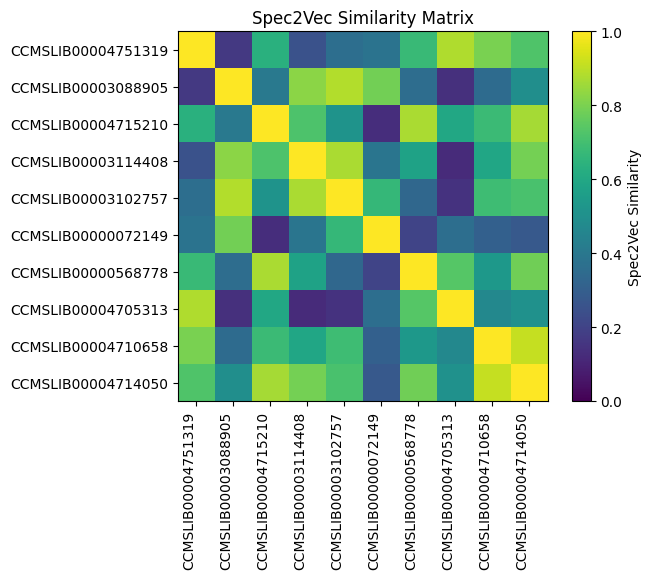

In [79]:
plt.imshow(S[:10, :10], cmap='viridis', vmin=0, vmax=1)
plt.title("Spec2Vec Similarity Matrix")
plt.xticks(ticks=np.arange(10), labels=[s.metadata.get('spectrum_id', 'Unknown') for s in valid_samples[:10]], rotation=90, ha='right')
plt.yticks(ticks=np.arange(10), labels=[s.metadata.get('spectrum_id', 'Unknown') for s in valid_samples[:10]])
plt.colorbar(label='Spec2Vec Similarity')
plt.show()

In [80]:
# comparison with cosine

scores = calculate_scores(valid_samples, valid_samples, similarity_measure, is_symmetric=True)
row, col, val = scores.scores['CosineGreedy_score']

n = len(valid_samples)
S = np.zeros((n, n))

S[row, col] = val

Calculating similarities: 100%|███████████████████████████████████████████| 751/751 [00:07<00:00, 97.87it/s]


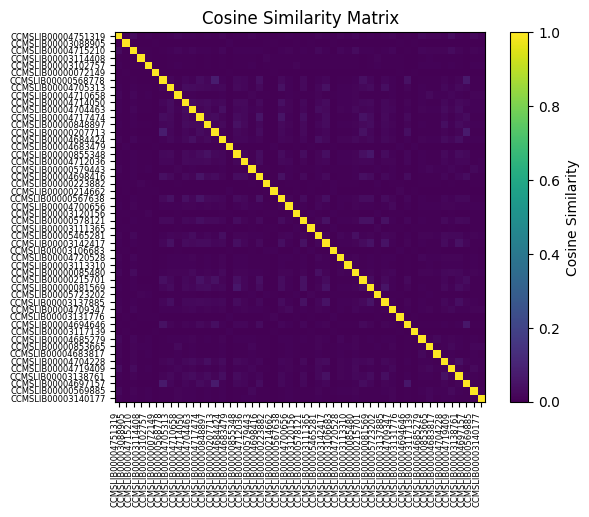

In [138]:
plt.imshow(S[:50, :50], cmap='viridis', vmin=0, vmax=1)
plt.title("Cosine Similarity Matrix")
plt.xticks(ticks=np.arange(50), labels=[s.metadata.get('spectrum_id', 'Unknown') for s in valid_samples[:50]], rotation=90, ha='right', fontsize=6)
plt.yticks(ticks=np.arange(50), labels=[s.metadata.get('spectrum_id', 'Unknown') for s in valid_samples[:50]], fontsize=6 )
plt.colorbar(label='Cosine Similarity')
plt.show()

### Earth Mover Distance

In [82]:
from masserstein import Spectrum
from scipy.stats import wasserstein_distance

W = wasserstein_distance(valid_samples[0].peaks.mz, valid_samples[1].peaks.mz, 
                     valid_samples[0].peaks.intensities, valid_samples[1].peaks.intensities)

similarity = 1 / (1 + W)  # convert distance to similarity
print(f"Wasserstein similarity: {similarity}")

Wasserstein similarity: 0.0026945877690267867


### Implementing Wasserstein similarity in matchms package

1. Implement W similarity as a parameter for calculate_scores

In [129]:
from matchms.similarity.BaseSimilarity import BaseSimilarity

class WassersteinSimilarity(BaseSimilarity):

    def pair(self, reference, query):
        # extract peak positions/intensities
        mz_ref = reference.peaks.mz
        mz_query = query.peaks.mz
        weight_ref = reference.peaks.intensities
        weight_query = query.peaks.intensities

        return 1 / (1 + wasserstein_distance(mz_ref, mz_query, weight_ref, weight_query))

In [130]:
wass_similarity = WassersteinSimilarity()

scores = matchms.calculate_scores(valid_samples,
                                  valid_samples, 
                                  wass_similarity, 
                                  is_symmetric=True)

Calculating similarities: 100%|███████████████████████████████████████████| 751/751 [00:20<00:00, 37.35it/s]


In [131]:
scores.score_names

('WassersteinSimilarity',)

In [132]:
row, col, val = scores.scores['WassersteinSimilarity']

n = len(valid_samples)
S = np.zeros((n, n))

S[row, col] = val  # convert distance to similarity

In [134]:
val

array([1.        , 0.00269459, 0.02825797, ..., 0.00756605, 0.00544229,
       1.        ])

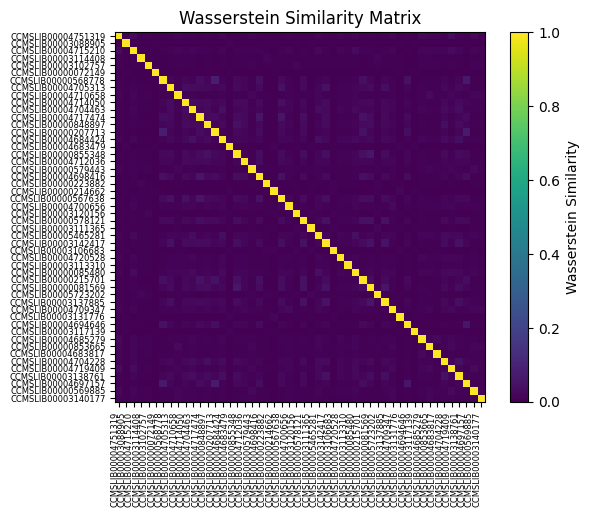

In [137]:
plt.imshow(S[:50, :50], cmap='viridis', vmin=0, vmax=1)
plt.title("Wasserstein Similarity Matrix")
plt.xticks(ticks=np.arange(50), labels=[s.metadata.get('spectrum_id', 'Unknown') for s in valid_samples[:50]], rotation=90, ha='right', fontsize=6)
plt.yticks(ticks=np.arange(50), labels=[s.metadata.get('spectrum_id', 'Unknown') for s in valid_samples[:50]], fontsize=6)
plt.colorbar(label='Wasserstein Similarity')
plt.show()

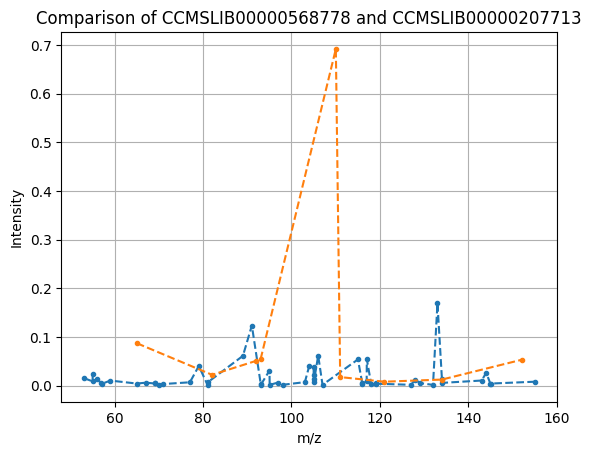

In [112]:
plt.plot(valid_samples[6].peaks.mz, valid_samples[6].peaks.intensities, '--.')
plt.plot(valid_samples[13].peaks.mz, valid_samples[13].peaks.intensities, '--.')
plt.title(f"Comparison of {valid_samples[6].metadata.get('spectrum_id', 'Unknown')} and {valid_samples[13].metadata.get('spectrum_id', 'Unknown')}")
plt.xlabel("m/z")
plt.ylabel("Intensity")
plt.grid()
plt.show()

### Closer look to masserstein (linear regression with W metric)
1. Read related paper 
2. Similarity matrix

In [173]:
a = Spectrum(
    confs=list(zip(
        mass_samples[0].peaks.mz,
        mass_samples[0].peaks.intensities
    ))
)

b = Spectrum(
    confs=list(zip(
        mass_samples[0].peaks.mz,
        mass_samples[0].peaks.intensities
    ))
)

result = estimate_proportions(
    spectrum=a,
    query=[b],
    progress=True,
    verbose=True,
    MTD = 0.2
)

Initial filtering of formulas: 100%|████████████████████████████████████████| 1/1 [00:00<00:00, 4148.67it/s]


IDs of theoretical spectra removed from query due to no matching experimental peaks: []
Envelope bounds: [(np.float64(131.050507), np.float64(377.106018), 0)]


Computing chunks: 100%|████████████████████████████████████████████████████| 1/1 [00:00<00:00, 13530.01it/s]


Number of chunks: 1
ChunkIDs: [0]
Chunk bounds: [(np.float64(130.85050700000002), np.float64(377.306018))]


Splitting the experimental spectrum into chunks: 87it [00:00, 1408897.48it/s]


Ion currents in chunks: [np.float64(0.9999999999999998)]


Deconvolving chunks: 100%|████████████████████████████████████████████████████| 1/1 [00:00<00:00, 11.71it/s]

Deconvolving chunk 0
Chunk %i deconvolution status: Optimal
Signal proportion in experimental spectrum: 1.0
Noise proportion in experimental spectrum: 0.0
Total explanation: 1.0


In [174]:
a = Spectrum(
    confs=list(zip(
        mass_samples[0].peaks.mz,
        mass_samples[0].peaks.intensities
    ))
)

b = Spectrum(
    confs=list(zip(
        mass_samples[1].peaks.mz,
        mass_samples[1].peaks.intensities
    ))
)

result = estimate_proportions(
    spectrum=a,
    query=[b],
    progress=True,
    verbose=True,
    MTD = 0.2
)

Initial filtering of formulas: 100%|████████████████████████████████████████| 1/1 [00:00<00:00, 7869.24it/s]


IDs of theoretical spectra removed from query due to no matching experimental peaks: []
Envelope bounds: [(np.float64(339.290161), np.float64(869.760559), 0)]


Computing chunks: 100%|█████████████████████████████████████████████████████| 1/1 [00:00<00:00, 9510.89it/s]


Number of chunks: 1
ChunkIDs: [0]
Chunk bounds: [(np.float64(339.090161), np.float64(869.960559))]


Splitting the experimental spectrum into chunks: 87it [00:00, 898779.43it/s]


Ion currents in chunks: [np.float64(0.3049047084613653)]


Deconvolving chunks: 100%|████████████████████████████████████████████████████| 1/1 [00:00<00:00, 13.59it/s]

Deconvolving chunk 0
Chunk %i deconvolution status: Optimal
Signal proportion in experimental spectrum: 0.0
Noise proportion in experimental spectrum: 1.000000005
Total explanation: 1.000000005


In [170]:
from masserstein import Spectrum, estimate_proportions

mass_samples = valid_samples[:10]
n = len(mass_samples)

P = np.zeros((n, n))

for i in range(n):

    observed = Spectrum(
        confs=list(zip(
            mass_samples[i].peaks.mz,
            mass_samples[i].peaks.intensities
        ))
    )

    ref_indices = [j for j in range(n) if j != i]

    references = [
        Spectrum(
            confs=list(zip(
                mass_samples[j].peaks.mz,
                mass_samples[j].peaks.intensities
            ))
        )
        for j in ref_indices
    ]

    result = estimate_proportions(
        spectrum=observed,
        query=references,
        progress=False,
        verbose=False,
        MTD = 0.4
    )

    # Fill off-diagonal entries
    for coeff, j in zip(result["proportions"], ref_indices):
        P[i, j] = coeff

    # Define self-similarity
    P[i, i] = 1.0


In [172]:
print(np.max(result["proportions"]))
print(np.sum(result["proportions"]))
print(result["noise"])

-0.0
0.0
[np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.003466516799999999), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.003560123699999999), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0028522131999999998), np.float64(0.14649998999999997), np.float64(0.012851809999999997), np.float64(0.0045679857999999995), np.float64(0.004366486699999999), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.

In [171]:
P

array([[ 1., -0., -0., -0., -0., -0., -0., -0., -0., -0.],
       [-0.,  1., -0., -0., -0., -0.,  0., -0., -0., -0.],
       [-0., -0.,  1., -0., -0., -0., -0., -0., -0., -0.],
       [-0., -0., -0.,  1., -0., -0., -0., -0., -0., -0.],
       [-0., -0., -0., -0.,  1., -0.,  0., -0., -0., -0.],
       [-0., -0., -0., -0., -0.,  1.,  0., -0., -0., -0.],
       [-0.,  0., -0., -0.,  0.,  0.,  1., -0., -0., -0.],
       [-0., -0., -0., -0., -0., -0., -0.,  1., -0., -0.],
       [-0., -0., -0., -0., -0., -0., -0., -0.,  1., -0.],
       [-0., -0., -0., -0., -0., -0., -0., -0., -0.,  1.]])

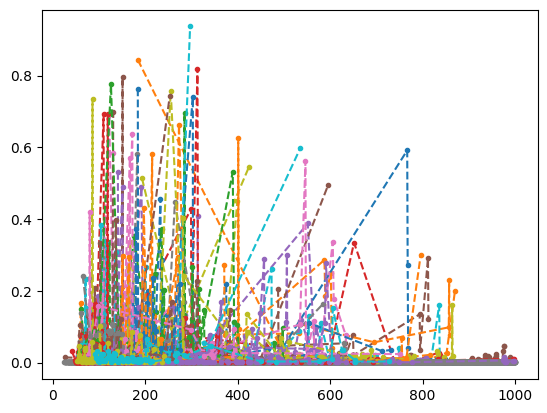

In [164]:
# plot mass_samples

for i in range(100):
  plt.plot(mass_samples[i].peaks.mz, mass_samples[i].peaks.intensities, '--.', label=f"{mass_samples[i].metadata.get('spectrum_id', 'Unknown')}")

### End